In [1]:
import numpy as np
import os
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from scipy.stats import ttest_1samp, ttest_rel
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_rdm

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


In [4]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = ['VLa', 'VLp', 'VPL']
palette = ['#D9B700', 'red', 'purple']
labels = ['100-0%,index', '75-25%,index', '50-50%,index', '25-75%,index', '75-25%,ring', '50-50%,ring', '25-75%,ring', '0-100%,ring']

Mean crossnobis dissimilarity against 0 (one-sided t-test):
VLa: tval=2.641, pval=0.010
VLp: tval=0.843, pval=0.207
VPL: tval=0.390, pval=0.351


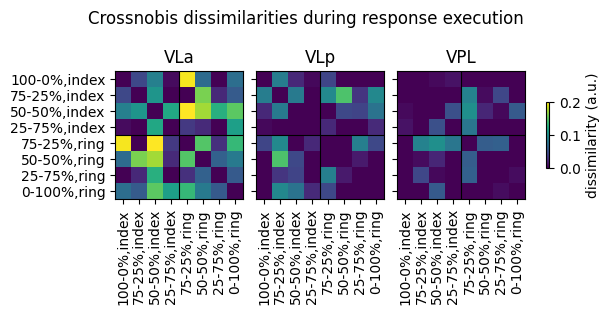

In [7]:
vmin, vmax = 0, .2

fig, axs = plt.subplots(1, len(rois), figsize=(6, 3),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.Thalamus.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, labels, vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].axhline(3.5, color='k', lw=.8)
    axs[r].axvline(3.5, color='k', lw=.8)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')
plt.show()